In [1]:
# EDA is completed for Apple Stock Price Predition and now 

# Data cleaned
# Trends identified
# Features created
# Stationarity checked
# Dataset is ready 
# Now the processed data is ready for Time Series Forecasting 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

import warnings
warnings.filterwarnings("ignore")

In [2]:
# # We load dataset

df = pd.read_csv("Processed_Apple_Stock_Data.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()

df = df[['Close']]  
df.head()

,Close
Date,
2012-01-03,58.747143
2012-01-04,59.062859
2012-01-05,59.718571
2012-01-06,60.342857
2012-01-09,60.247143


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2011 non-null   float64
dtypes: float64(1)
memory usage: 31.4 KB


In [4]:
df.describe()

,Close
count,2011.000000
mean,126.741235
std,50.578369
min,55.790001
25%,86.202145
50%,113.050003
75%,165.245002
max,291.519989


In [5]:
df.isnull().sum()

Close    0
dtype: int64

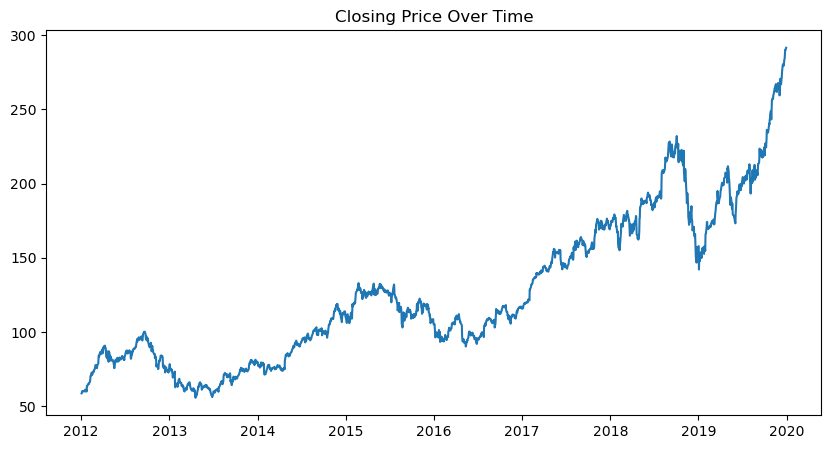

In [6]:
# Visualize data

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Closing Price Over Time")
plt.show()

In [7]:
df['Target'] = df['Close'].shift(-30)
df.dropna(inplace=True)

In [8]:
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)

df.dropna(inplace=True)
df['MA10'] = df['Close'].rolling(10).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df['Volatility'] = df['Close'].rolling(10).std()

df.dropna(inplace=True)

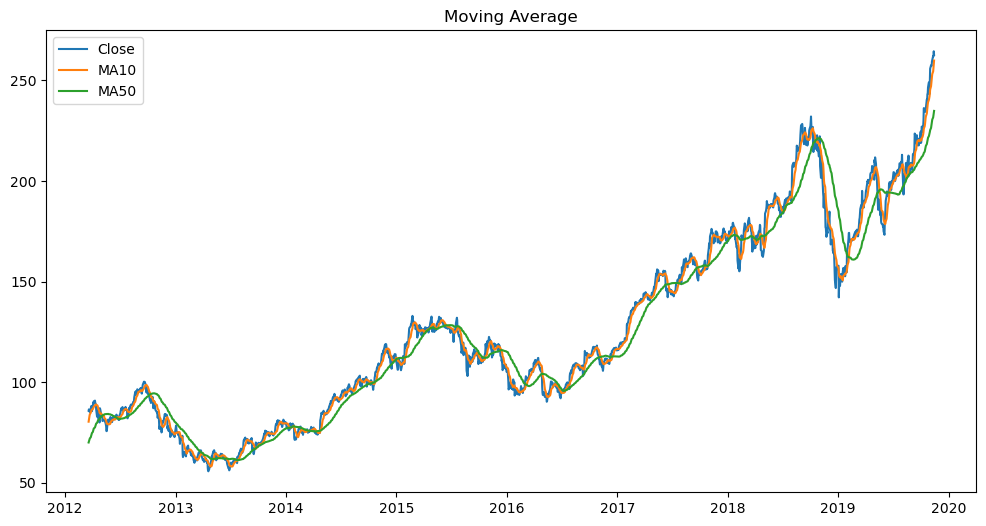

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA10'], label='MA10')
plt.plot(df['MA50'], label='MA50')
plt.legend()
plt.title('Moving Average')
plt.show()

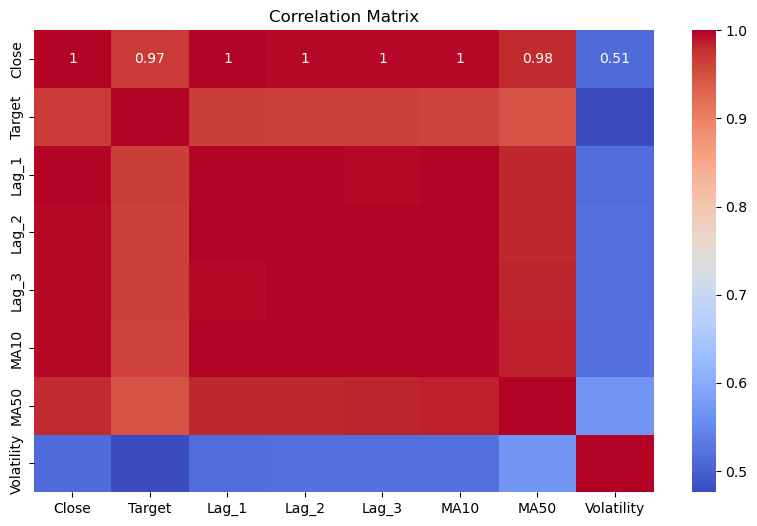

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [11]:
df['Close_log'] = np.log(df['Close'])

In [12]:
# Let us check stationarity using Augmented Dickey Fuller Test(ADF) 

def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(df['Close_log'])

ADF Statistic: 0.14535684656377154
p-value: 0.9690248160228032


In [13]:
# Make Data Stationary (Differencing)
# Differencing removes trend and stabilizes mean.
# a technique used to transform non-stationary 
# time series data into stationary data by subtracting the current observation from the previous one

df['Close_log_diff'] = df['Close_log'].diff()

adf_test(df['Close_log_diff'])

ADF Statistic: -15.686064244061185
p-value: 1.4529373660439714e-28


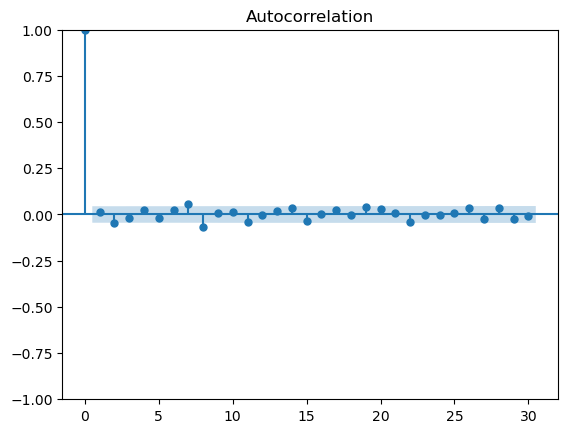

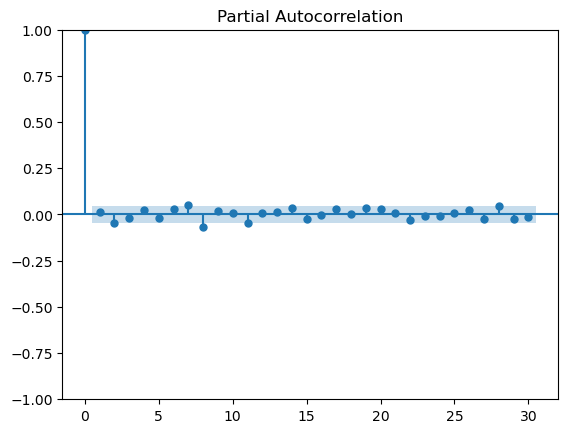

In [14]:
# ACF and PACF Plots
# ACF- Autocorrelation Function
# PACF - Partial Autocorrelation Function

# ACF and PACF plots helped us determine the number of lag terms needed in the ARIMA model.
# Lag terms refer to previous time steps in the data that are used to predict the current value.(A lag term means using past values of the data to predict the current value.)
# For example, today’s stock price may depend on yesterday’s price or the price two days ago. These previous values are called lag terms.
# In ARIMA, the number of lag terms is determined using ACF and PACF plots. PACF helps us choose the number of autoregressive terms
# (p), while ACF helps us choose the number of moving average terms (q).

plot_acf(df['Close_log_diff'].dropna(), lags=30)
plot_pacf(df['Close_log_diff'].dropna(), lags=30)
plt.show()

In [15]:
# Split Data (Train/Test)
# We split the dataset into training and testing sets to evaluate model performance.
# We use 80% training and 20% testing

train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [16]:
def evaluate(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{name} RMSE:", rmse)
    print(f"{name} MAE :", mae)
    print(f"{name} MAPE:", mape)
    print("-"*30)

    return rmse, mae, mape

In [17]:
# Baseline Model(Naive Method)

naive_pred = test.shift(1)

rmse_naive = np.sqrt(mean_squared_error(test[1:], naive_pred[1:]))
print("Naive RMSE:", rmse_naive)

Naive RMSE: 2.477720305187334


# ARIMA

In [18]:
arima_model = ARIMA(train['Close'], order=(1,1,1))
arima_fit = arima_model.fit()

pickle.dump(arima_fit, open("arima_model.pkl", "wb"))

arima_pred = arima_fit.forecast(steps=len(test))

evaluate(test['Close'], arima_pred, "ARIMA")

ARIMA RMSE: 27.662159281247632
ARIMA MAE : 22.001903069799656
ARIMA MAPE: nan
------------------------------


(27.662159281247632, 22.001903069799656, nan)

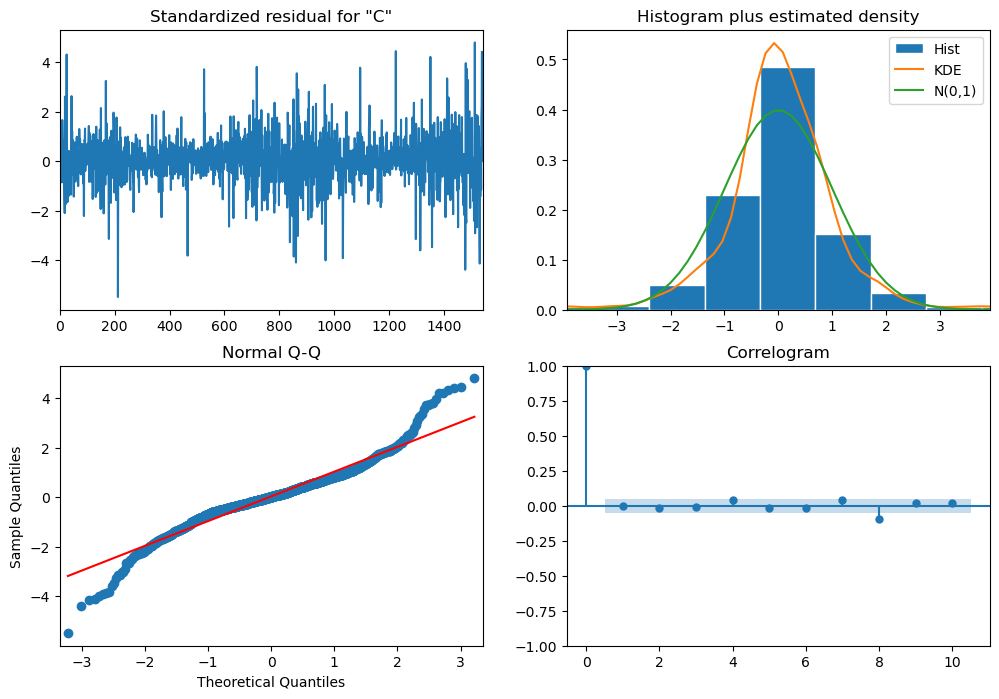

In [45]:
# Residual diagnostics
# Residual diagnostics help us check whether the model has captured all patterns in the data.


arima_fit.plot_diagnostics(figsize=(12,8))
plt.show()

# SARIMA

In [19]:
sarima_model = SARIMAX(
    train['Close'],
    order=(1,1,1),
    seasonal_order=(1,1,1,5)
)

sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.forecast(steps=len(test))

evaluate(test['Close'], sarima_pred, "SARIMA")

SARIMA RMSE: 22.254758899486294
SARIMA MAE : 17.19168384897088
SARIMA MAPE: nan
------------------------------


(22.254758899486294, 17.19168384897088, nan)

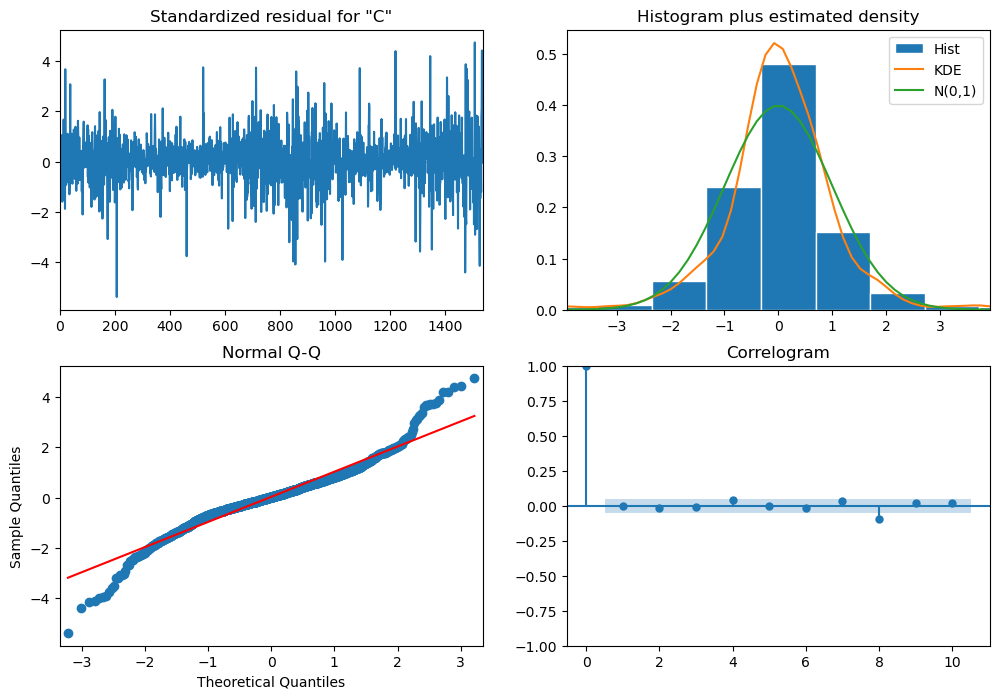

In [21]:
sarima_fit.plot_diagnostics(figsize=(12,8))
plt.show()

# SARIMAX

In [22]:
# 1. Create lag feature
df['lag1'] = df['Close'].shift(1)

# 2. Drop NA AFTER feature creation
df = df.dropna()

# 3. Train-test split (AFTER cleaning)
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

# 4. Define target
y_train = train['Close']
y_test = test['Close']

# 5. Exogenous variables (IMPORTANT: must align with y)
exog_train = train[['lag1']]   # safer than Open/Volume unless cleaned
exog_test = test[['lag1']]

# 6. Fit SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(y_train,
                        exog=exog_train,
                        order=(1,1,1),
                        seasonal_order=(1,1,1,5))

sarimax_fit = sarimax_model.fit()

# 7. Forecast
sarimax_pred = sarimax_fit.forecast(steps=len(y_test), exog=exog_test)

# DEEP LEARNING METHODS

In [23]:
# SCALING DATA

scaler = MinMaxScaler()

train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[['Close']])
test_scaled = scaler.transform(test[['Close']])

In [24]:
# CREATE SEQUENCES

seq_len = 50

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, seq_len)

combined = np.vstack((train_scaled[-seq_len:], test_scaled))
X_test, y_test = create_sequences(combined, seq_len)

# LSTM MODEL

In [25]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_len,1)),
    Dropout(0.2),
    
    LSTM(32),
    Dropout(0.2),
    
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - loss: 0.0260
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0038
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0037
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0035
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0036
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0038
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0031
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0026
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0026
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0027
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0030
Epoch 12/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0025
Epoch 13/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0024
Epoch 14/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0024
Epoch 15/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0021
Epo

# GRU 

In [26]:
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(seq_len,1)),
    Dropout(0.2),
    
    GRU(32),
    Dropout(0.2),
    
    Dense(1)
])

In [27]:
def evaluate_all(y_true, y_pred, model_name):
    # Convert prediction to Series if not already
    if not isinstance(y_pred, pd.Series):
        y_pred = pd.Series(y_pred)

    # Force same index length safely
    evaluate(test['Close'], arima_pred, "ARIMA")
    y_true = y_true[-min_len:]
    y_pred = y_pred[-min_len:]

    # Reset index to avoid mismatch issues
    y_true = y_true.reset_index(drop=True)
    y_pred = y_pred.reset_index(drop=True)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

In [28]:
results = []

def collect(y_true, y_pred, name):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    
    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    results.append([name, rmse, mae])

collect(test['Close'], arima_pred, "ARIMA")
collect(test['Close'], sarima_pred, "SARIMA")
collect(y_test, sarimax_pred, "SARIMAX")
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
# LSTM prediction inverse scaling
lstm_pred = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred)

# GRU prediction inverse scaling

gru_pred = gru_model.predict(X_test)
gru_pred = scaler.inverse_transform(gru_pred)

# TRUE values inverse scaling
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
collect(y_test_inv, lstm_pred, "LSTM")
collect(y_test_inv, gru_pred, "GRU")
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE"])
print(results_df.sort_values(by="RMSE"))

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step
     Model        RMSE         MAE
3     LSTM    7.447559    6.320966
1   SARIMA   22.254759   17.191684
0    ARIMA   27.662159   22.001903
4      GRU  133.503285  131.712843
2  SARIMAX  194.651040  194.510156


In [29]:
results_df.sort_values(by="RMSE")

,Model,RMSE,MAE
3,LSTM,7.447559,6.320966
1,SARIMA,22.254759,17.191684
0,ARIMA,27.662159,22.001903
4,GRU,133.503285,131.712843
2,SARIMAX,194.651040,194.510156


In [30]:
# FULL MODEL COMPARISON PLOT

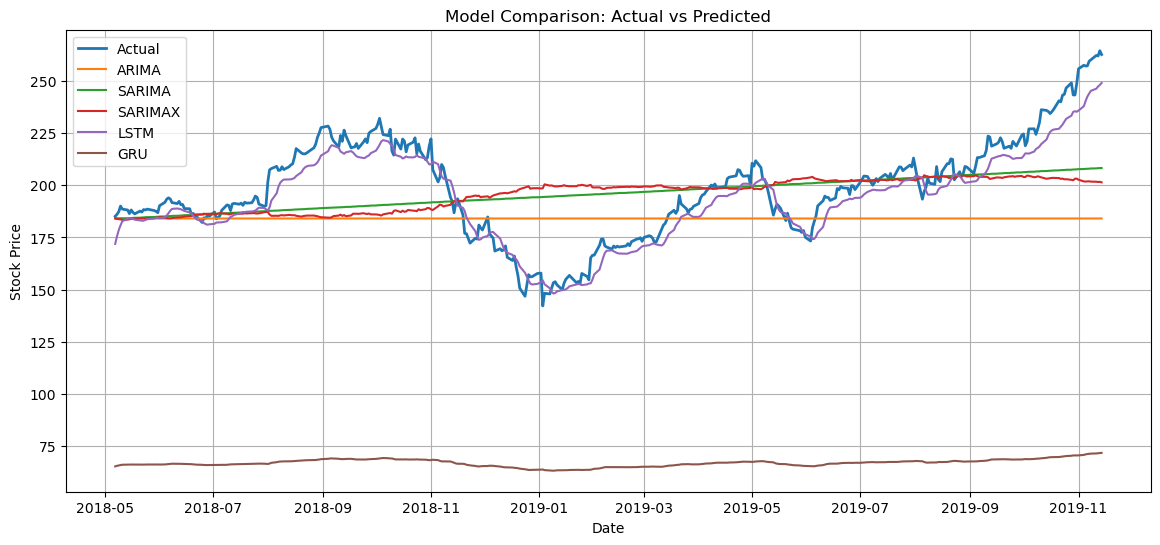

In [31]:
plt.figure(figsize=(14,6))

# Actual
plt.plot(test.index, test['Close'], label='Actual', linewidth=2)

# --- ARIMA ---
min_len = min(len(test), len(arima_pred))
plt.plot(test.index[:min_len], np.array(arima_pred)[:min_len], label='ARIMA')

# --- SARIMA ---
min_len = min(len(test), len(sarima_pred))
plt.plot(test.index[:min_len], np.array(sarima_pred)[:min_len], label='SARIMA')


# --- SARIMAX ---
min_len = min(len(test), len(sarimax_pred))
plt.plot(test.index[-min_len:], np.array(sarimax_pred)[-min_len:], label='SARIMAX')

# --- LSTM ---
min_len = min(len(test), len(lstm_pred))
plt.plot(test.index[-min_len:], np.array(lstm_pred).flatten()[-min_len:], label='LSTM')

# --- GRU ---
min_len = min(len(test), len(gru_pred))
plt.plot(test.index[-min_len:], np.array(gru_pred).flatten()[-min_len:], label='GRU')

plt.title("Model Comparison: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid()

plt.show()

In [32]:
# “Different models produce predictions with slightly different lengths due to lagging, differencing, and sequence windows. 
# So we aligned them before visualization to ensure fair comparison.”

In [33]:
# BEST MODEL HIGHLIGHT PLOT

best_model = results_df.sort_values(by="RMSE").iloc[0]
print(best_model)

Model        LSTM
RMSE     7.447559
MAE      6.320966
Name: 3, dtype: object


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

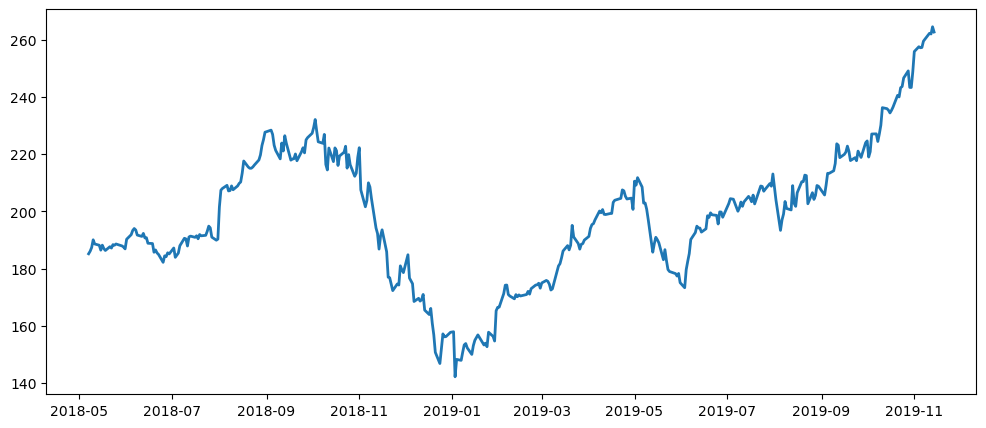

In [44]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test['Close'], label='Actual', linewidth=2)

if best_model == "SARIMAX":
    plt.plot(test.index[-len(sarimax_pred):], sarimax_pred, label='SARIMAX')
elif best_model == "LSTM":
    plt.plot(test.index[-len(lstm_pred):], lstm_pred, label='LSTM')
elif best_model == "GRU":
    plt.plot(test.index[-len(gru_pred):], gru_pred, label='GRU')

plt.title(f"Best Model vs Actual ({best_model})")
plt.legend()
plt.grid()

plt.show()

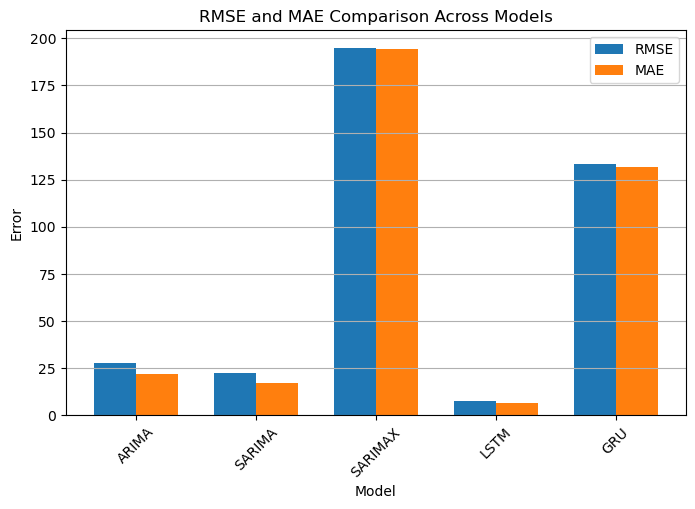

In [35]:
# ERROR COMPARISON BAR CHART

x = np.arange(len(results_df['Model']))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, results_df['RMSE'], width, label='RMSE')
plt.bar(x + width/2, results_df['MAE'], width, label='MAE')

plt.title("RMSE and MAE Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Error")

plt.xticks(x, results_df['Model'], rotation=45)

plt.legend()
plt.grid(axis='y')

plt.show()

In [36]:
# Save

plt.savefig("model_comparison.png")

<Figure size 640x480 with 0 Axes>

In [37]:
# This project implemented and compared multiple time series forecasting models, including ARIMA, SARIMA, SARIMAX, LSTM, and GRU, 
# to predict stock prices. The models were evaluated using RMSE and MAE metrics on the test dataset.

# The LSTM (Long Short-Term Memory) model achieved the lowest RMSE and MAE, making it the best-performing model for this dataset.

In [38]:
# The superior performance of LSTM can be attributed to:

        # Its ability to capture long-term dependencies in sequential data
        # Effectiveness in modeling non-linear patterns in stock prices
        # Use of sequence-based learning, which leverages historical context more efficiently than traditional models

In [39]:
# The study concludes that LSTM is the most suitable model for this stock price forecasting task due to its superior accuracy and 
# ability to model complex temporal patterns effectively.

In [40]:
lstm_model.save("lstm_model.keras")

In [41]:
from tensorflow.keras.models import load_model

model = load_model("lstm_model.keras")

In [42]:
model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.90688]], dtype=float32)